# Prepare the list of cities from GHSL UCDB

## Read before you start

This notebook builds the city table the rest of the BEM4AI pipeline is keyed on. It selects
European urban centres from the Global Human Settlement Layer (GHSL) Urban Centre Database, keeps
those in countries covered by the Hotmaps building stock, and cuts a 2x2 km window around each city
centre out of OpenStreetMap and of three GHSL rasters.

This is the only stage that needs the large raw downloads. Together they exceed 100 GB and a full
run takes hours depending on the machine, most of it in the OSM extraction; a laptop is enough.
Once the per-city extracts and chips exist the raw downloads can be deleted — the last cell, left
commented out, does that — and this notebook does not have to run again.

The notebook writes the per-city OSM extracts to `data/OSM PBF/cities_osm_pbf/`, the raster chips
to `data/GHS_BuiltC_cities/`, `data/GHS_BuiltH_cities/` and `data/GHS_BuiltAge_cities/`, and the
city tables to `data/interim/`. It creates every folder it needs; the only ones you put files into
yourself are the two download folders named in the table below.

### Platform note

The OSM sections need the `osmium-tool` command-line program, which runs on macOS and Linux only.
On Windows, run this notebook under WSL2 (Windows Subsystem for Linux). `BEM4AI_3_Buildings.ipynb` and the notebooks after it are
cross-platform.

### Required inputs

Download and extract the archives below before running. Keep the official release names: the
notebook looks for these directories and files exactly as they are published.

| Input archive | Download | Extracted location | Used for |
|---|---|---|---|
| `GHS_UCDB_REGION_EUROPE_R2024A_V1_0.zip` | [Catalogue](https://data.jrc.ec.europa.eu/dataset/1a338be6-7eaf-480c-9664-3a8ade88cbcd) and [direct download](https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_UCDB_GLOBE_R2024A/GHS_UCDB_REGION_GLOBE_R2024A/GHS_UCDB_REGION_EUROPE_R2024A/V1-0/) | `data/GHSL/GHS_UCDB_REGION_EUROPE_R2024A_V1_0/`, containing `GHS_UCDB_REGION_EUROPE_R2024A.xlsx` and `GHS_UCDB_REGION_EUROPE_R2024A.gpkg` | City attributes, names, and spatial geometries. |
| `GHS_BUILT_C_MSZ_E2018_GLOBE_R2023A_54009_10_V1_0.zip` | [Catalogue](https://data.jrc.ec.europa.eu/dataset/3c60ddf6-0586-4190-854b-f6aa0edc2a30) and [direct download](https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_BUILT_C_GLOBE_R2023A/GHS_BUILT_C_MSZ_E2018_GLOBE_R2023A_54009_10/V1-0/) | `data/GHSL/GHS_BUILT_C_MSZ_E2018_GLOBE_R2023A_54009_10_V1_0/` | Settlement morphology and land-use chips. |
| `GHS_BUILT_H_ANBH_E2018_GLOBE_R2023A_54009_100_V1_0.zip` | [Catalogue](https://data.jrc.ec.europa.eu/dataset/85005901-3a49-48dd-9d19-6261354f56fe) and [direct download](https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_BUILT_H_GLOBE_R2023A/GHS_BUILT_H_ANBH_E2018_GLOBE_R2023A_54009_100/V1-0/) | `data/GHSL/GHS_BUILT_H_ANBH_E2018_GLOBE_R2023A_54009_100_V1_0/GHS_BUILT_H_ANBH_E2018_GLOBE_R2023A_54009_100_V1_0.tif` | Building-height chips. |
| `GHS_AGE_1975052020_GLOBE_R2025A_54009_100_V1_0.zip` | [Catalogue](https://data.jrc.ec.europa.eu/dataset/d503bb56-9884-4e4d-bb8f-d86711d9f749) and [direct download](https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_AGE_GLOBE_R2025A/V1-0/) | `data/GHSL/GHS_AGE_1975052020_GLOBE_R2025A_54009_100_V1_0/GHS_AGE_1975052020_GLOBE_R2025A_54009_100_V1_0.tif` | Construction-epoch chips. |
| `building_stock.csv` | [Hotmaps building stock data](https://gitlab.com/hotmaps/building-stock/-/tree/master/data) | `data/building_stock/building_stock.csv` | Defines which countries have building stock data. Cities in other countries are dropped. |
| Per-country `.osm.pbf` files | Geofabrik links, listed in the OSM section below | `data/OSM PBF/country_pbf/` | OSM extraction. Only the countries that hold cities in the dataset are needed. |

`config/indicator_attribute_mapping.csv` ships with this repository and selects which UCDB attributes
are read. It is required, but it is not an external download.

The notebook is meant to be run top to bottom. The OSM sections cannot be skipped even if only
the raster chips are wanted, because the set of cities in the dataset is settled by which extracts
contain buildings.


## Load and extract selected GHS UCDB attributes

**Inputs**

- GHS UCDB dataset `GHS_UCDB_REGION_EUROPE_R2024A.xlsx`
- Mapping file `config/indicator_attribute_mapping.csv` selecting the target attributes
- `config/geography.json`, which the country and Geofabrik cells below read

**Steps**

1. Import the libraries, resolve the source files and the per-city output folders, and declare the GHSL column names and the window size that every later cell reuses.
2. Read the mapping file and iterate over the tables it lists, skipping any the workbook does not contain, so that a different UCDB region file reports what is missing instead of failing.
3. Take the mapped columns from each table and concatenate them in mapping order.

**Outputs**
DataFrame `cities_raw` holding the mapped UCDB attributes for every European urban centre.


In [1]:
from pathlib import Path
import json
import math
import platform
import shutil
import subprocess
import tempfile

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import rasterio
from pyrosm import OSM
from rasterio.warp import Resampling, reproject
from shapely.geometry import box

from helpers.config import load_json_config
from helpers.paths import PROJECT_ROOT, DATA_DIR, INTERIM_DIR, display_path
from helpers.ghsl_chips import (
    AGE_CMAP,
    AGE_LABELS,
    AGE_NORM,
    BUILTC_CMAP,
    BUILTC_LABELS,
    BUILTC_NODATA,
    BUILTC_NORM,
    build_city_chips,
    preview_chips,
)
from helpers.utils import bbox_around_latlon, clean_city_name, collapse_whitespace

# Source data downloaded and extracted as described above
GHSL_DIR = DATA_DIR / "GHSL"
UCDB_DIR = GHSL_DIR / "GHS_UCDB_REGION_EUROPE_R2024A_V1_0"
UCDB_XLSX = UCDB_DIR / "GHS_UCDB_REGION_EUROPE_R2024A.xlsx"
UCDB_GPKG = UCDB_DIR / "GHS_UCDB_REGION_EUROPE_R2024A.gpkg"
MAPPING_CSV = PROJECT_ROOT / "config" / "indicator_attribute_mapping.csv"
BUILDING_STOCK_DIR = DATA_DIR / "building_stock"
BUILDING_STOCK_CSV = BUILDING_STOCK_DIR / "building_stock.csv"
BUILTC_TILES = GHSL_DIR / "GHS_BUILT_C_MSZ_E2018_GLOBE_R2023A_54009_10_V1_0"
BUILTH_RASTER = (GHSL_DIR / "GHS_BUILT_H_ANBH_E2018_GLOBE_R2023A_54009_100_V1_0"
                 / "GHS_BUILT_H_ANBH_E2018_GLOBE_R2023A_54009_100_V1_0.tif")
AGE_RASTER = (GHSL_DIR / "GHS_AGE_1975052020_GLOBE_R2025A_54009_100_V1_0"
              / "GHS_AGE_1975052020_GLOBE_R2025A_54009_100_V1_0.tif")

# Per-city outputs written by this notebook
OSM_DIR = DATA_DIR / "OSM PBF"
COUNTRY_PBF_DIR = OSM_DIR / "country_pbf"      # per-country Geofabrik downloads
CITIES_PBF_DIR = OSM_DIR / "cities_osm_pbf"    # per-city extracts
BUILTC_DIR = DATA_DIR / "GHS_BuiltC_cities"
BUILTH_DIR = DATA_DIR / "GHS_BuiltH_cities"
AGE_DIR = DATA_DIR / "GHS_BuiltAge_cities"

for directory in (INTERIM_DIR, BUILDING_STOCK_DIR, COUNTRY_PBF_DIR, CITIES_PBF_DIR,
                  BUILTC_DIR, BUILTH_DIR, AGE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# GHSL column names and shared parameters
CITY_COL = "GC_UCN_MAI_2025"
LAT_COL = "GC_UCC_LAT_2025"
LON_COL = "GC_UCC_LON_2025"
COUNTRY_COL = "GC_CNT_GAD_2025"

KM_HALF = 1.0              # half-side of the city window: 1 km -> 2x2 km
MAX_FEATS_PER_CITY = 5000  # cap on the OSM footprints drawn per city
PREVIEW_CITIES = 4         # cities shown in the preview grids

GEOGRAPHY_CONFIG = load_json_config("geography.json")

# Extract the UCDB attributes selected in the mapping file
mapping = pd.read_csv(MAPPING_CSV)
collected = {}

with pd.ExcelFile(UCDB_XLSX) as workbook:
    for table_name, group in mapping.groupby("Table"):
        if table_name not in workbook.sheet_names:
            print(f"Table '{table_name}' not in the UCDB workbook, skipping.")
            continue
        table = pd.read_excel(workbook, sheet_name=table_name)
        for column in group["Attribute ID"]:
            if column in table.columns:
                collected[column] = table[column]

ordered = [column for column in mapping["Attribute ID"] if column in collected]
cities_raw = pd.concat([collected[column] for column in ordered], axis=1)
cities_raw.head()

,GC_CNT_GAD_2025,GC_UCN_MAI_2025,GC_UCN_LIS_2025,GC_UCA_KM2_2025,GC_POP_TOT_2025,GH_BUT_P12_2020,GH_BUT_P13_2020,GH_AGE_S75_2025,GH_AGE_S85_2025,GH_AGE_S95_2025,...,SC_SEC_PCY_2020,SC_SEC_PCA_2020,SC_SEC_PCO_2020,GR_SHB_HGR_2020,GR_SHB_GRN_2020,CL_KOP_CUR_2025,CL_REN_PVO_2020,CL_REN_W01_2020,CL_REN_W05_2020,CL_WDS_CUR_2010
0,Spain,Los Cristianos,Los Cristianos,22,61040.00135,53404.634800,2846.685883,91.759100,7.228857,0.878019,...,14.797735,65.187095,20.015170,0.001782,0.048381,6.0,4.683400,2.044964,2.872762,54.625160
1,Portugal,Funchal,Funchal; Câmara de Lobos,46,135362.23400,105695.587900,0.000000,76.328861,1.470382,1.439019,...,13.121732,64.560110,22.318159,0.020855,0.056051,9.0,3.925169,2.289424,3.398155,59.896137
2,Iceland,Reykjavik,Reykjavik,97,206894.88360,52877.795670,0.000000,91.431391,1.125087,1.328174,...,19.211056,65.296038,15.492906,0.001588,0.062754,16.0,NaN,5.095012,7.016746,44.967064
3,Ireland,Galway,Galway,36,73625.42370,19645.204900,0.000000,64.955417,7.526612,11.663647,...,22.106900,63.436315,14.456785,0.020590,0.056179,15.0,2.558327,4.995089,7.671137,70.904259
4,United Kingdom,Derry/Londonderry,Derry/Londonderry,29,70080.19886,6748.440392,0.000000,75.797644,3.669198,9.489878,...,17.699290,63.743387,18.557322,0.024367,0.064988,15.0,2.363538,4.812084,7.200963,65.428741


## Append the city centroids from the GeoPackage

The tabular UCDB release has no coordinates. The GeoPackage holds one urban-centre polygon per
city in Mollweide (ESRI:54009), and the centroid of that polygon is the city centre this dataset
uses. Every later stage cuts its window around this point, so the definition is fixed: the
GeoPackage also ships a `UC_centroids` layer of population-weighted centroids, and switching to it
would move every OSM extract and every GHSL chip. The join uses `validate="m:1"` because the layer is expected to contain exactly one polygon for each city; a changed release should stop the workflow rather than silently duplicate city rows.

**Inputs**
GeoPackage `GHS_UCDB_REGION_EUROPE_R2024A.gpkg` from the same UCDB release, and `cities_raw`.

**Steps**

1. Read the general-characteristics layer, which holds one polygon per city together with all three join keys.
2. Take the polygon centroid in the layer's own projected CRS, then convert it to WGS84.
3. Left-join the coordinates onto `cities_raw` as `GC_UCC_LAT_2025` and `GC_UCC_LON_2025`.

**Outputs**
DataFrame `cities_with_coords`, and a printed count of the cities that received coordinates.


In [2]:
CENTROID_LAYER = "GHSL_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A"
JOIN_KEYS = ["GC_CNT_GAD_2025", "GC_UCN_MAI_2025", "GC_UCN_LIS_2025"]

centres = gpd.read_file(UCDB_GPKG, layer=CENTROID_LAYER)
centroids = centres.geometry.centroid.to_crs(4326)
centres[LAT_COL] = centroids.y
centres[LON_COL] = centroids.x

cities_with_coords = cities_raw.merge(
    centres[JOIN_KEYS + [LAT_COL, LON_COL]], how="left", on=JOIN_KEYS, validate="m:1",
)
print(f"Centroids from '{CENTROID_LAYER}': "
      f"{cities_with_coords[LAT_COL].notna().sum()} of {len(cities_with_coords)} cities.")
cities_with_coords[JOIN_KEYS + [LAT_COL, LON_COL]].head()

Centroids from 'GHSL_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A': 1165 of 1165 cities.


,GC_CNT_GAD_2025,GC_UCN_MAI_2025,GC_UCN_LIS_2025,GC_UCC_LAT_2025,GC_UCC_LON_2025
0,Spain,Los Cristianos,Los Cristianos,28.067028,-16.725552
1,Portugal,Funchal,Funchal; Câmara de Lobos,32.654493,-16.932136
2,Iceland,Reykjavik,Reykjavik,64.120592,-21.893943
3,Ireland,Galway,Galway,53.273929,-9.047943
4,United Kingdom,Derry/Londonderry,Derry/Londonderry,55.007445,-7.320151


## Filter the cities to continental Europe

**Inputs**
`cities_with_coords`.

**Steps**

1. Keep the cities inside 35-66 N and -10-40 E. This drops the overseas territories of countries that are otherwise in the dataset - the Canaries, Madeira, the Azores, the French overseas departments - whose climate and building stock do not match their mainland, along with cities further east and north than the sources cover.
2. Move the two coordinate columns to the end of the table, latitude first.

**Outputs**
`cities_df`, the working city table that the rest of the notebook narrows further.


In [3]:
LAT_MIN, LAT_MAX = 35.0, 66.0
LON_MIN, LON_MAX = -10.0, 40.0

cities_df = cities_with_coords[
    cities_with_coords[LAT_COL].between(LAT_MIN, LAT_MAX)
    & cities_with_coords[LON_COL].between(LON_MIN, LON_MAX)
].copy()

# Keep the coordinate columns at the end of the table, with latitude before longitude.
attributes = [c for c in cities_df.columns if c not in (LAT_COL, LON_COL)]
cities_df = cities_df[attributes + [LAT_COL, LON_COL]]

print(f"Kept {len(cities_df)} of {len(cities_with_coords)} cities inside "
      f"{LAT_MIN}-{LAT_MAX} N, {LON_MIN}-{LON_MAX} E.")
cities_df.head()

Kept 974 of 1165 cities inside 35.0-66.0 N, -10.0-40.0 E.


,GC_CNT_GAD_2025,GC_UCN_MAI_2025,GC_UCN_LIS_2025,GC_UCA_KM2_2025,GC_POP_TOT_2025,GH_BUT_P12_2020,GH_BUT_P13_2020,GH_AGE_S75_2025,GH_AGE_S85_2025,GH_AGE_S95_2025,...,SC_SEC_PCO_2020,GR_SHB_HGR_2020,GR_SHB_GRN_2020,CL_KOP_CUR_2025,CL_REN_PVO_2020,CL_REN_W01_2020,CL_REN_W05_2020,CL_WDS_CUR_2010,GC_UCC_LAT_2025,GC_UCC_LON_2025
3,Ireland,Galway,Galway,36,73625.42370,19645.204900,0.000000,64.955417,7.526612,11.663647,...,14.456785,0.020590,0.056179,15.0,2.558327,4.995089,7.671137,70.904259,53.273929,-9.047943
4,United Kingdom,Derry/Londonderry,Derry/Londonderry,29,70080.19886,6748.440392,0.000000,75.797644,3.669198,9.489878,...,18.557322,0.024367,0.064988,15.0,2.363538,4.812084,7.200963,65.428741,55.007445,-7.320151
5,France,Brest,Brest,42,127488.81410,105448.852600,6288.963701,89.993918,1.872351,2.711573,...,20.260323,0.005227,0.039654,15.0,3.065917,3.751234,6.023508,71.516022,48.395744,-4.489251
6,Jersey,St. Helier,St. Helier; St. Saviour,24,58332.71829,31447.180330,0.000000,83.667195,4.161115,4.505812,...,17.047085,0.010185,0.064188,15.0,3.235027,4.961163,7.015735,63.096230,49.178033,-2.085608
7,Belgium,Ostend,Ostend,35,82243.27412,53440.829360,2966.211365,69.720124,7.805159,9.732028,...,19.131060,0.003989,0.046033,15.0,3.076816,4.486160,6.829675,55.910252,51.223731,2.931636


## Filter the cities to the countries covered by the building stock

**Inputs**
`cities_df`, and the building stock table `data/building_stock/building_stock.csv`.

**Steps**

1. Read the distinct country list from the building stock CSV and drop the `EU27+UK` rows, which aggregate the other countries rather than describing one.
2. Apply the country synonyms from `config/geography.json` so the GHSL country labels match the building stock spellings, and keep only the cities whose country is covered.
3. Add the stable `city_key` used by the OSM extracts, the GHSL chips and every later stage.

**Outputs**
`cities_df` reduced to the covered countries, with a `city_key` column.

The country list is read from the source CSV rather than from a database, so this stage does not need a populated `building_stock` schema. `BEM4AI_2_Archetypes.ipynb` builds its `cities` table from the same list, so both stages always agree on the scope of the dataset.


In [4]:
if not BUILDING_STOCK_CSV.exists():
    raise FileNotFoundError(
        f"Missing building stock table: {BUILDING_STOCK_CSV}\n"
        f"Download it from https://gitlab.com/hotmaps/building-stock/-/tree/master/data "
        f"and place it in {BUILDING_STOCK_DIR} before running this notebook."
    )

# Exclude aggregate pseudo-country rows.
aggregates = set(GEOGRAPHY_CONFIG["aggregate_countries"])
stock_countries = sorted(
    set(pd.read_csv(BUILDING_STOCK_CSV, sep="|", usecols=["country"])["country"]
        .dropna().astype(str))
    - aggregates
)
stock_keys = {country.casefold() for country in stock_countries}

# Resolve GHSL country labels to the corresponding building-stock names.
synonyms = GEOGRAPHY_CONFIG["country_synonyms"]
country_in_stock = (
    cities_df[COUNTRY_COL]
    .map(collapse_whitespace)
    .map(lambda name: synonyms.get(name, name))
)
covered = country_in_stock.str.casefold().isin(stock_keys)

before = len(cities_df)
skipped = sorted(set(country_in_stock.loc[~covered].dropna()))
cities_df = cities_df.loc[covered].copy()

# Create the stable key used by every later stage and per-city artifact.
cities_df["city_key"] = cities_df[CITY_COL].map(clean_city_name)

print(f"{len(stock_countries)} countries with building stock data: {', '.join(stock_countries)}")
print(f"\nSkipped, no building stock data: {', '.join(skipped) if skipped else '-'}")
print(f"\nKept {len(cities_df)} of {before} cities in {cities_df[COUNTRY_COL].nunique()} "
      f"of them. Cyprus has no urban centre in the UCDB Europe release.")
cities_df.head()

28 countries with building stock data: Austria, Belgium, Bulgaria, Croatia, Cyprus, Czech Republic, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Ireland, Italy, Latvia, Lithuania, Luxembourg, Malta, Netherlands, Poland, Portugal, Romania, Slovakia, Slovenia, Spain, Sweden, United Kingdom

Skipped, no building stock data: Albania, Belarus, Bosnia and Herzegovina, Jersey, Kosovo, Moldova, Montenegro, North Macedonia, Norway, Russian Federation, Serbia, Switzerland, Ukraine

Kept 745 of 974 cities in 27 of them. Cyprus has no urban centre in the UCDB Europe release.


,GC_CNT_GAD_2025,GC_UCN_MAI_2025,GC_UCN_LIS_2025,GC_UCA_KM2_2025,GC_POP_TOT_2025,GH_BUT_P12_2020,GH_BUT_P13_2020,GH_AGE_S75_2025,GH_AGE_S85_2025,GH_AGE_S95_2025,...,GR_SHB_HGR_2020,GR_SHB_GRN_2020,CL_KOP_CUR_2025,CL_REN_PVO_2020,CL_REN_W01_2020,CL_REN_W05_2020,CL_WDS_CUR_2010,GC_UCC_LAT_2025,GC_UCC_LON_2025,city_key
3,Ireland,Galway,Galway,36,73625.42370,19645.204900,0.000000,64.955417,7.526612,11.663647,...,0.020590,0.056179,15.0,2.558327,4.995089,7.671137,70.904259,53.273929,-9.047943,Galway
4,United Kingdom,Derry/Londonderry,Derry/Londonderry,29,70080.19886,6748.440392,0.000000,75.797644,3.669198,9.489878,...,0.024367,0.064988,15.0,2.363538,4.812084,7.200963,65.428741,55.007445,-7.320151,Derry_Londonderry
5,France,Brest,Brest,42,127488.81410,105448.852600,6288.963701,89.993918,1.872351,2.711573,...,0.005227,0.039654,15.0,3.065917,3.751234,6.023508,71.516022,48.395744,-4.489251,Brest
7,Belgium,Ostend,Ostend,35,82243.27412,53440.829360,2966.211365,69.720124,7.805159,9.732028,...,0.003989,0.046033,15.0,3.076816,4.486160,6.829675,55.910252,51.223731,2.931636,Ostend
8,Netherlands,Maasvlakte,Maasvlakte; Slag Maasmond,26,53774.57522,30974.720790,4951.615257,52.631768,8.289736,24.498239,...,0.000184,0.041852,15.0,3.073712,4.960609,7.304319,59.263794,51.959616,4.043910,Maasvlakte


## Initialize the `city_assets_df` source-asset registry

**Inputs**
`cities_df`.

**Steps**

1. Take one row per `city_key` with its name, country and centroid, and rename the GHSL columns to the short names the later stages use.
2. Add `country_key`, the filename-safe spelling of the country used for the per-country PBFs.
3. Add the empty asset columns that the cells below fill in: `osm_pbf`, `builtc_tif`, `builth_tif`, `builtage_tif`.

**Outputs**
DataFrame `city_assets_df` with one row per city, keyed by `city_key`.


In [5]:
city_assets_df = (
    cities_df[[CITY_COL, COUNTRY_COL, LAT_COL, LON_COL, "city_key"]]
    .drop_duplicates(subset="city_key")
    .rename(columns={CITY_COL: "city_ghsl", COUNTRY_COL: "country",
                     LAT_COL: "lat", LON_COL: "lon"})
    .reset_index(drop=True)
)
city_assets_df["country_key"] = city_assets_df["country"].map(clean_city_name)

# Initialize one source-asset column for each artifact created below.
for column in ["osm_pbf", "builtc_tif", "builth_tif", "builtage_tif"]:
    city_assets_df[column] = pd.Series(dtype="object")

city_assets_df

,city_ghsl,country,lat,lon,city_key,country_key,osm_pbf,builtc_tif,builth_tif,builtage_tif
0,Galway,Ireland,53.273929,-9.047943,Galway,Ireland,NaN,NaN,NaN,NaN
1,Derry/Londonderry,United Kingdom,55.007445,-7.320151,Derry_Londonderry,United_Kingdom,NaN,NaN,NaN,NaN
2,Brest,France,48.395744,-4.489251,Brest,France,NaN,NaN,NaN,NaN
3,Ostend,Belgium,51.223731,2.931636,Ostend,Belgium,NaN,NaN,NaN,NaN
4,Maasvlakte,Netherlands,51.959616,4.043910,Maasvlakte,Netherlands,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
740,Folkestone,United Kingdom,51.083874,1.167172,Folkestone,United_Kingdom,NaN,NaN,NaN,NaN
741,Norwich,United Kingdom,52.638878,1.283935,Norwich,United_Kingdom,NaN,NaN,NaN,NaN
742,Margate,United Kingdom,51.365929,1.401444,Margate,United_Kingdom,NaN,NaN,NaN,NaN
743,Great Yarmouth,United Kingdom,52.590021,1.721444,Great_Yarmouth,United_Kingdom,NaN,NaN,NaN,NaN


# Extract the per-city OSM PBFs

## Download the per-country OSM PBFs from Geofabrik

Download the country files with your browser and place them in `data/OSM PBF/country_pbf/`. The **next cell** reports which countries the dataset needs, renames the downloads to a canonical `<Country>.osm.pbf`, and lists whatever is still missing. Re-run it after each download. Geofabrik stamps a date into the filename (e.g. `czech-republic-260909.osm.pbf`), which the rename handles.

### Why Osmium

`osmium-tool` cuts many city extracts from one country file in a single pass, and its `complete_ways` strategy pulls in every node a building references, so no footprint comes out broken. It works offline, unlike the Overpass API, and is far faster than the Python readers for batch work.

| Country (GHSL name) | Download |
|---|---|
| Austria | [austria-latest.osm.pbf](https://download.geofabrik.de/europe/austria-latest.osm.pbf) |
| Belgium | [belgium-latest.osm.pbf](https://download.geofabrik.de/europe/belgium-latest.osm.pbf) |
| Bulgaria | [bulgaria-latest.osm.pbf](https://download.geofabrik.de/europe/bulgaria-latest.osm.pbf) |
| Croatia | [croatia-latest.osm.pbf](https://download.geofabrik.de/europe/croatia-latest.osm.pbf) |
| Czechia | [czech-republic-latest.osm.pbf](https://download.geofabrik.de/europe/czech-republic-latest.osm.pbf) |
| Denmark | [denmark-latest.osm.pbf](https://download.geofabrik.de/europe/denmark-latest.osm.pbf) |
| Estonia | [estonia-latest.osm.pbf](https://download.geofabrik.de/europe/estonia-latest.osm.pbf) |
| Finland | [finland-latest.osm.pbf](https://download.geofabrik.de/europe/finland-latest.osm.pbf) |
| France | [france-latest.osm.pbf](https://download.geofabrik.de/europe/france-latest.osm.pbf) |
| Germany | [germany-latest.osm.pbf](https://download.geofabrik.de/europe/germany-latest.osm.pbf) |
| Greece | [greece-latest.osm.pbf](https://download.geofabrik.de/europe/greece-latest.osm.pbf) |
| Hungary | [hungary-latest.osm.pbf](https://download.geofabrik.de/europe/hungary-latest.osm.pbf) |
| Ireland | [ireland-and-northern-ireland-latest.osm.pbf](https://download.geofabrik.de/europe/ireland-and-northern-ireland-latest.osm.pbf) |
| Italy | [italy-latest.osm.pbf](https://download.geofabrik.de/europe/italy-latest.osm.pbf) |
| Latvia | [latvia-latest.osm.pbf](https://download.geofabrik.de/europe/latvia-latest.osm.pbf) |
| Lithuania | [lithuania-latest.osm.pbf](https://download.geofabrik.de/europe/lithuania-latest.osm.pbf) |
| Luxembourg | [luxembourg-latest.osm.pbf](https://download.geofabrik.de/europe/luxembourg-latest.osm.pbf) |
| Malta | [malta-latest.osm.pbf](https://download.geofabrik.de/europe/malta-latest.osm.pbf) |
| Netherlands | [netherlands-latest.osm.pbf](https://download.geofabrik.de/europe/netherlands-latest.osm.pbf) |
| Poland | [poland-latest.osm.pbf](https://download.geofabrik.de/europe/poland-latest.osm.pbf) |
| Portugal | [portugal-latest.osm.pbf](https://download.geofabrik.de/europe/portugal-latest.osm.pbf) |
| Romania | [romania-latest.osm.pbf](https://download.geofabrik.de/europe/romania-latest.osm.pbf) |
| Slovakia | [slovakia-latest.osm.pbf](https://download.geofabrik.de/europe/slovakia-latest.osm.pbf) |
| Slovenia | [slovenia-latest.osm.pbf](https://download.geofabrik.de/europe/slovenia-latest.osm.pbf) |
| Spain | [spain-latest.osm.pbf](https://download.geofabrik.de/europe/spain-latest.osm.pbf) |
| Sweden | [sweden-latest.osm.pbf](https://download.geofabrik.de/europe/sweden-latest.osm.pbf) |
| United Kingdom | [great-britain-latest.osm.pbf](https://download.geofabrik.de/europe/great-britain-latest.osm.pbf) |


In [6]:
# List the country files that still need to be downloaded.
geofabrik = GEOGRAPHY_CONFIG["geofabrik"]
slugs_by_country = geofabrik["country_slugs"]

country_pbf_map, missing = {}, []

for country, country_key in (city_assets_df[["country", "country_key"]]
                             .drop_duplicates().sort_values("country_key")
                             .itertuples(index=False)):
    canonical = COUNTRY_PBF_DIR / f"{country_key}.osm.pbf"
    if canonical.exists():
        country_pbf_map[country_key] = canonical
        continue

    # Some countries have more than one Geofabrik filename, such as Great Britain and the United Kingdom.
    slugs = slugs_by_country.get(country, [])
    downloaded = [p for slug in slugs for p in sorted(COUNTRY_PBF_DIR.glob(f"{slug}*.osm.pbf"))]
    if downloaded:
        downloaded[-1].rename(canonical)
        country_pbf_map[country_key] = canonical
        print(f"  [renamed] {downloaded[-1].name} -> {canonical.name}")
    elif slugs:
        url = f"{geofabrik['base_url']}/{geofabrik['region']}/{slugs[0]}-latest.osm.pbf"
        missing.append((country, url))
    else:
        missing.append((country, "no Geofabrik slug in config/geography.json"))

print(f"{len(country_pbf_map)} of {len(country_pbf_map) + len(missing)} country PBFs "
      f"ready in {display_path(COUNTRY_PBF_DIR)}.")
for country, where in missing:
    print(f"  [missing] {country}: {where}")

27 of 27 country PBFs ready in data/OSM PBF/country_pbf.


## Extract the per-city OSM subsets, country by country

**Inputs**
`city_assets_df` and the per-country `.osm.pbf` files in `data/OSM PBF/country_pbf/`.

**Steps**

1. Group the cities by country and skip the ones whose extract already exists.
2. Split the remaining cities into small batches, each holding one 2x2 km bounding box per city.
3. Run `osmium extract` once per batch with the complete-way strategy, writing into a temporary staging directory.
4. Move each finished extract into `cities_osm_pbf/` and record its filename in `city_assets_df["osm_pbf"]`.

**Outputs**
One `<city_key>.osm.pbf` per city, and a populated `osm_pbf` column.

Osmium memory use grows with both the number of simultaneous extracts and the largest OSM node ID in the country file, so large countries such as France are processed in small batches. An empty PBF left by an interrupted run is treated as missing and re-extracted.


In [7]:
OVERWRITE = False              # set True to re-extract city PBFs that already exist
MAX_EXTRACTS_PER_BATCH = 10    # safe for large country PBFs on a 24 GB machine

if platform.system() == "Windows":
    raise RuntimeError(
        "osmium-tool is not available on Windows. Run this notebook on macOS, Linux or "
        "WSL2; BEM4AI_3_Buildings.ipynb and the notebooks after it run on all platforms."
    )
if not shutil.which("osmium"):
    raise FileNotFoundError("`osmium` CLI not found. On macOS: brew install osmium-tool")


def has_content(path: Path) -> bool:
    return path.is_file() and path.stat().st_size > 0


extracts_by_city = {}

for country_key, group in city_assets_df.groupby("country_key"):
    source_pbf = country_pbf_map.get(country_key)
    if source_pbf is None:
        print(f"  [skip] no country PBF for {country_key}")
        continue

    pending = []
    for row in group.itertuples(index=False):
        out_pbf = CITIES_PBF_DIR / f"{row.city_key}.osm.pbf"
        if has_content(out_pbf) and not OVERWRITE:
            extracts_by_city[row.city_key] = out_pbf.name
        else:
            pending.append(row)

    batches = math.ceil(len(pending) / MAX_EXTRACTS_PER_BATCH)
    for number, start in enumerate(range(0, len(pending), MAX_EXTRACTS_PER_BATCH), start=1):
        batch = pending[start:start + MAX_EXTRACTS_PER_BATCH]

        # Use a temporary directory so interrupted runs never expose partial extracts.
        with tempfile.TemporaryDirectory(prefix=f".{country_key}_", dir=CITIES_PBF_DIR) as staging:
            staging_dir = Path(staging)
            config = {"extracts": [
                {"output": str(staging_dir / f"{row.city_key}.osm.pbf"),
                 "bbox": list(bbox_around_latlon(row.lat, row.lon, KM_HALF))}
                for row in batch
            ]}
            config_path = staging_dir / "extracts.json"
            config_path.write_text(json.dumps(config))

            print(f"  [extract] {country_key} batch {number}/{batches}: {len(batch)} cities")
            # Use complete ways to retain every node required by each building footprint.
            subprocess.run(
                ["osmium", "extract", "--config", str(config_path), "--strategy",
                 "complete_ways", "--progress", str(source_pbf)],
                check=True,
            )

            for row in batch:
                staged = staging_dir / f"{row.city_key}.osm.pbf"
                if has_content(staged):
                    staged.replace(CITIES_PBF_DIR / staged.name)
                    extracts_by_city[row.city_key] = staged.name

city_assets_df["osm_pbf"] = city_assets_df["city_key"].map(extracts_by_city)

print(f"\nCity extracts available: {city_assets_df['osm_pbf'].notna().sum()} "
      f"of {len(city_assets_df)}")
city_assets_df[["city_key", "country", "osm_pbf"]].head()

  [extract] Bulgaria batch 1/1: 1 cities


[======================================================================] 100% 


  [extract] Spain batch 1/1: 1 cities



City extracts available: 745 of 745


[======================================================================] 100% 


,city_key,country,osm_pbf
0,Galway,Ireland,Galway.osm.pbf
1,Derry_Londonderry,United Kingdom,Derry_Londonderry.osm.pbf
2,Brest,France,Brest.osm.pbf
3,Ostend,Belgium,Ostend.osm.pbf
4,Maasvlakte,Netherlands,Maasvlakte.osm.pbf


## Drop the cities whose extract holds no buildings

A city centre can fall outside the mapped area of OSM, leaving an extract with no building at all.
Such cities cannot produce a BEM model, so they are dropped here rather than failing in a later
stage - as is any city whose extract is missing entirely.

Reading every extract with `pyrosm` takes several minutes, so each outcome is cached in
`data/interim/pbf_building_status.csv` (columns `osm_pbf` and `has_buildings`). After a kernel
restart only extracts that were never checked are read again; delete the file to force a full
re-check. Only the outcome of a successful read is cached, so a read that fails stops the notebook
instead of quietly removing the city from every later run.

**Inputs**
`city_assets_df`, the per-city extracts, and the cache file when an earlier run wrote one.

**Steps**

1. Define `load_city_buildings`, which every later cell uses to read the polygonal footprints of one city.
2. Load the cache and read only the extracts it does not cover yet, appending the new results to it.
3. Drop the cities with no buildings from `city_assets_df` and from `cities_df`.

**Outputs**
`city_assets_df` and `cities_df` restricted to the cities with at least one OSM building, and an
extended cache file.


In [8]:
BUILDING_STATUS_CSV = INTERIM_DIR / "pbf_building_status.csv"


def load_city_buildings(pbf_name, max_features=None):
    """Polygonal OSM building footprints of one city extract, optionally downsampled."""
    osm = OSM(str(CITIES_PBF_DIR / pbf_name))
    try:
        buildings = osm.get_buildings()
    except Exception:
        # Some extracts cannot be read through Pyrosm; the raw tag filter remains available.
        buildings = osm.get_data_by_custom_criteria(
            custom_filter={"building": True}, filter_type="keep", keep_nodes=False,
        )
    if buildings is None or buildings.empty:
        return None
    buildings = buildings[buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
    if buildings.empty:
        return None
    if max_features and len(buildings) > max_features:
        buildings = buildings.sample(max_features, random_state=42)
    return buildings


if BUILDING_STATUS_CSV.exists():
    status = pd.read_csv(BUILDING_STATUS_CSV)
else:
    status = pd.DataFrame(columns=["osm_pbf", "has_buildings"])

checked = dict(zip(status["osm_pbf"], status["has_buildings"]))
pbf_names = city_assets_df["osm_pbf"].dropna().unique()
unchecked = [name for name in pbf_names if name not in checked]
print(f"Building presence: {len(pbf_names) - len(unchecked)} of {len(pbf_names)} extracts "
      f"taken from {display_path(BUILDING_STATUS_CSV)}, {len(unchecked)} read now.")

if unchecked:
    # Stop on read errors rather than caching them as no buildings and excluding the city later.
    for name in unchecked:
        checked[name] = load_city_buildings(name) is not None
    status = (pd.concat([status, pd.DataFrame(
                  [{"osm_pbf": name, "has_buildings": checked[name]} for name in unchecked])],
              ignore_index=True)
              .drop_duplicates(subset="osm_pbf", keep="last"))
    status.to_csv(BUILDING_STATUS_CSV, index=False)

empty = city_assets_df.loc[~city_assets_df["osm_pbf"].map(lambda n: bool(checked.get(n, False)))]
if not empty.empty:
    print(f"Dropping {len(empty)} cities with no buildings: {', '.join(empty['city_key'])}")

city_assets_df = city_assets_df.drop(index=empty.index).reset_index(drop=True)
cities_df = cities_df[
    cities_df["city_key"].isin(city_assets_df["city_key"])
].copy()
print(f"Cities with OSM buildings: {len(city_assets_df)}")

Building presence: 0 of 745 extracts taken from data/interim/pbf_building_status.csv, 745 read now.
Cities with OSM buildings: 745


## Preview the first city extracts

A quick look at the first `PREVIEW_CITIES` extracts, to confirm that Osmium cut real building footprints before the notebook moves on to the raster layers.

**Inputs**
`city_assets_df` and the per-city extracts.

**Outputs**
One panel of black footprints per city.


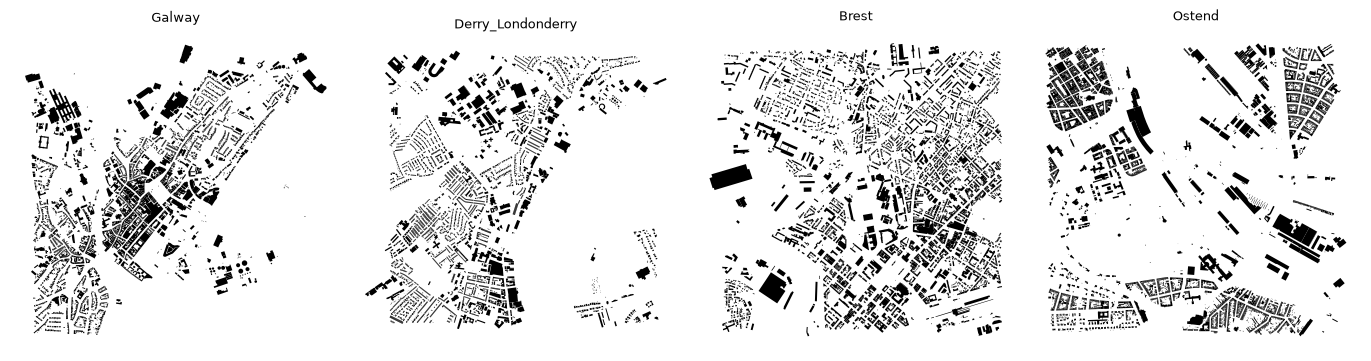

In [9]:
preview = city_assets_df.head(PREVIEW_CITIES)

fig, axes = plt.subplots(1, len(preview), figsize=(3.4 * len(preview), 3.5),
                         constrained_layout=True)
for ax, row in zip(np.atleast_1d(axes), preview.itertuples(index=False)):
    load_city_buildings(row.osm_pbf, MAX_FEATS_PER_CITY).plot(
        ax=ax, linewidth=0.0, facecolor="black")
    ax.set_title(row.city_key, fontsize=9)
    ax.axis("off")
plt.show()

# Further data about the cities

## GHSL Built-C chips (settlement morphology)

The three GHSL layers are cut around the same city centres as the OSM extracts. Built-C is a 10 m tile set, Built-H and AGE are single global rasters, so the clipping, the caching and the previews live in `helpers/ghsl_chips.py` and each layer here is one call. Every layer keeps its own CRS and nodata value; nothing is carried over between layers.

The OSM extract is the 2x2 km box around the centre in degrees. A chip is that same box projected into the layer's Mollweide CRS and then squared off, which makes it somewhat larger - about 2.1 x 2.0 km in Portugal and 2.5 x 2.0 km on the Black Sea coast, because the distortion grows with distance from the central meridian. The chip therefore always covers its OSM extract, which is what the later stages need: stage 3 reads these rasters at building coordinates, not as per-city areas. The `2x2km` in the filenames is the nominal window, not the extent of the file.

**Inputs**
`city_assets_df` (`city_key`, `lat`, `lon`) and the global GHSL Built-C tiles.

**Steps**

1. Build the WGS84 box around each city centroid and project it into the tile CRS.
2. Mosaic the overlapping tiles inside that bounding box and write a single-band uint8 GeoTIFF with `nodata = 255`.
3. Record the chip filename in `city_assets_df["builtc_tif"]` and preview the first few.

**Outputs**
One `<city_key>_GHS_BUILT_C_2x2km_moll.tif` per city in `data/GHS_BuiltC_cities/`, and a populated `builtc_tif` column.

A chip that already exists and opens cleanly is reused, so re-running after a kernel restart only writes what is missing. Chips are written through a temporary file and renamed, so an interrupted run leaves nothing half-written behind. Set `OVERWRITE_CHIPS = True` to force a full rebuild.


Built-C chips in data/GHS_BuiltC_cities: 745 (reused 743, newly written 2)


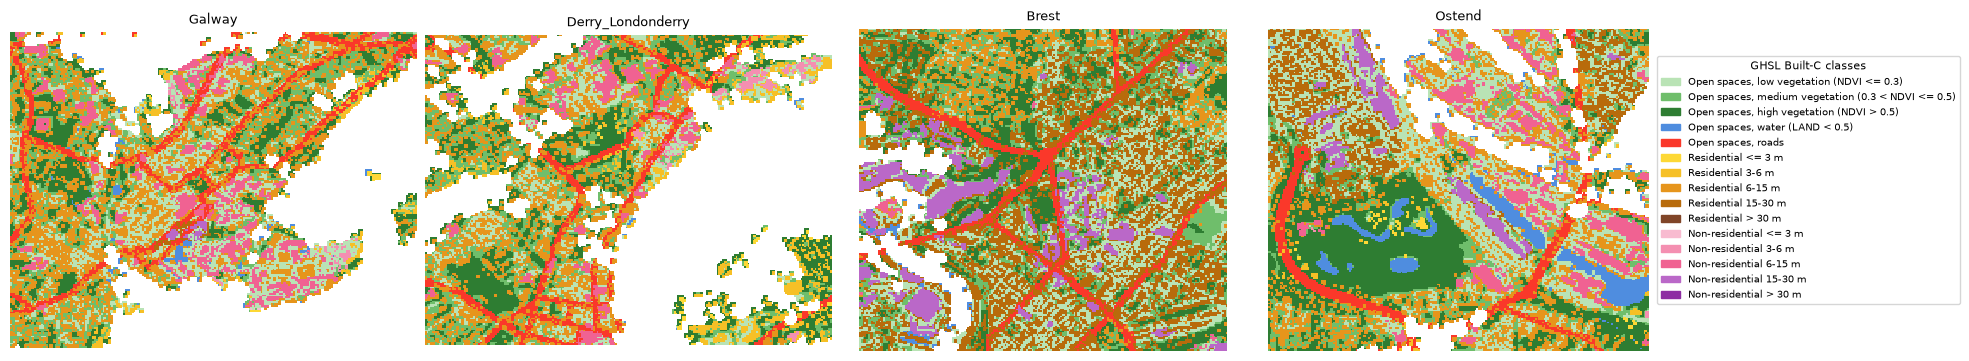

In [10]:
OVERWRITE_CHIPS = False  # set True to rebuild chips that are already on disk

builtc_chips = build_city_chips(
    city_assets_df, BUILTC_TILES, BUILTC_DIR, "GHS_BUILT_C_2x2km_moll",
    label="Built-C", km_half=KM_HALF, nodata=BUILTC_NODATA, dtype="uint8",
    overwrite=OVERWRITE_CHIPS,
)
city_assets_df["builtc_tif"] = city_assets_df["city_key"].map(builtc_chips)

preview_chips(builtc_chips, BUILTC_DIR, cmap=BUILTC_CMAP, norm=BUILTC_NORM,
              labels=BUILTC_LABELS, legend_title="GHSL Built-C classes",
              n=PREVIEW_CITIES)

## GHSL Built-H chips (building heights)

Same window, same caching, read from the single global 100 m average net building height raster instead of a tile set. Float heights and the raster's own nodata value are preserved.

**Inputs**
`city_assets_df` and `GHS_BUILT_H_ANBH_E2018_GLOBE_R2023A_54009_100_V1_0.tif`.

**Outputs**
One `<city_key>_GHS_BUILT_H_2x2km_moll.tif` per city in `data/GHS_BuiltH_cities/`, a populated `builth_tif` column, and a preview with a shared height colorbar.


Built-H chips in data/GHS_BuiltH_cities: 745 (reused 743, newly written 2)


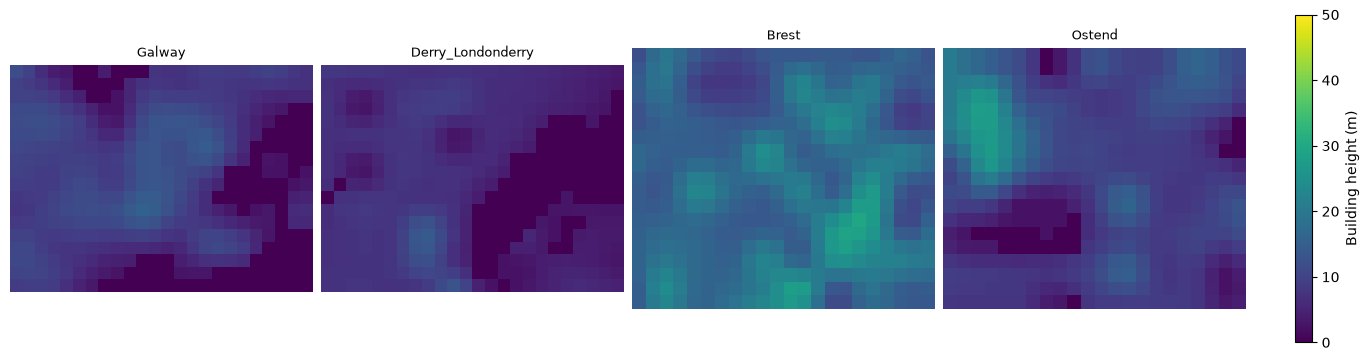

In [11]:
builth_chips = build_city_chips(
    city_assets_df, BUILTH_RASTER, BUILTH_DIR, "GHS_BUILT_H_2x2km_moll",
    label="Built-H", km_half=KM_HALF, overwrite=OVERWRITE_CHIPS,
)
city_assets_df["builth_tif"] = city_assets_df["city_key"].map(builth_chips)

preview_chips(builth_chips, BUILTH_DIR, cmap="viridis", vmin=0, vmax=50,
              colorbar_label="Building height (m)", n=PREVIEW_CITIES)

## GHSL AGE chips (construction epoch)

Same window and caching again, read from the global 100 m construction epoch raster. The epoch codes are categorical, so the chip keeps its source dtype and nodata value.

**Inputs**
`city_assets_df` and `GHS_AGE_1975052020_GLOBE_R2025A_54009_100_V1_0.tif`.

**Outputs**
One `<city_key>_GHS_AGE_2x2km_moll.tif` per city in `data/GHS_BuiltAge_cities/`, a populated `builtage_tif` column, and a preview with the official epoch palette.


AGE chips in data/GHS_BuiltAge_cities: 745 (reused 743, newly written 2)


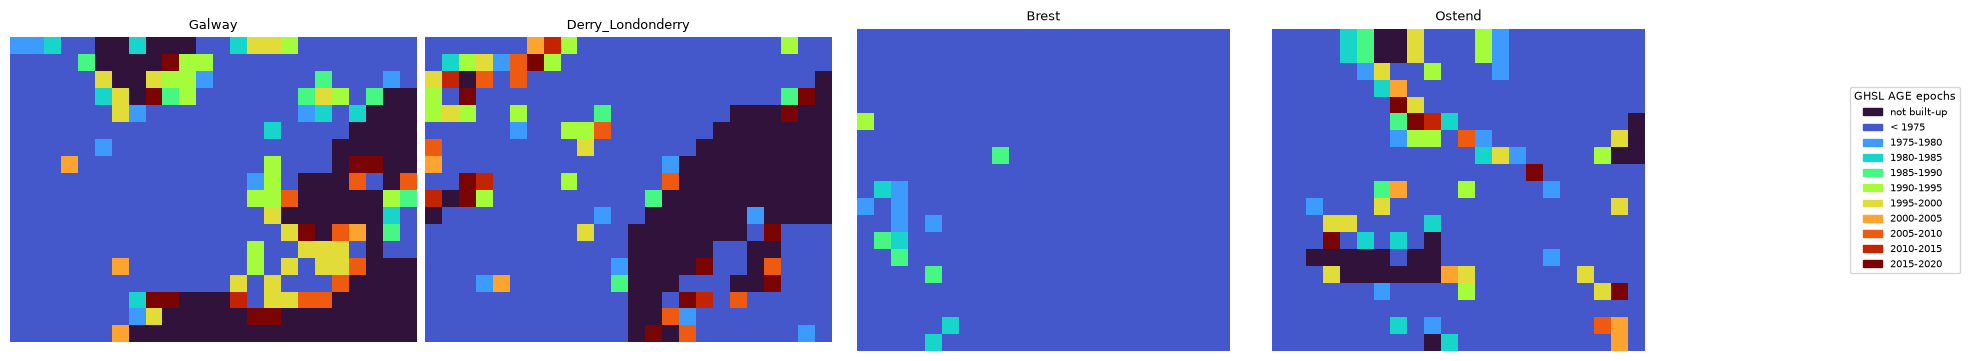

In [12]:
age_chips = build_city_chips(
    city_assets_df, AGE_RASTER, AGE_DIR, "GHS_AGE_2x2km_moll",
    label="AGE", km_half=KM_HALF, overwrite=OVERWRITE_CHIPS,
)
city_assets_df["builtage_tif"] = city_assets_df["city_key"].map(age_chips)

preview_chips(age_chips, AGE_DIR, cmap=AGE_CMAP, norm=AGE_NORM, labels=AGE_LABELS,
              legend_title="GHSL AGE epochs", n=PREVIEW_CITIES)

## Check that the four assets of one city line up

**Inputs**
One city, and its `osm_pbf`, `builtc_tif`, `builth_tif` and `builtage_tif` entries in `city_assets_df`.

**Steps**

1. Take the Built-C chip as the reference grid: it is the finest of the three at 10 m.
2. Resample the 100 m Built-H and AGE chips onto that grid, padding the edges with NaN.
3. Reproject the OSM footprints into the Built-C CRS and clip them to the same window.
4. Draw the four layers over the same map window, in projected coordinates.

**Outputs**
Four aligned maps of the chosen city: OSM footprints, Built-C classes, Built-H heights and AGE epochs.


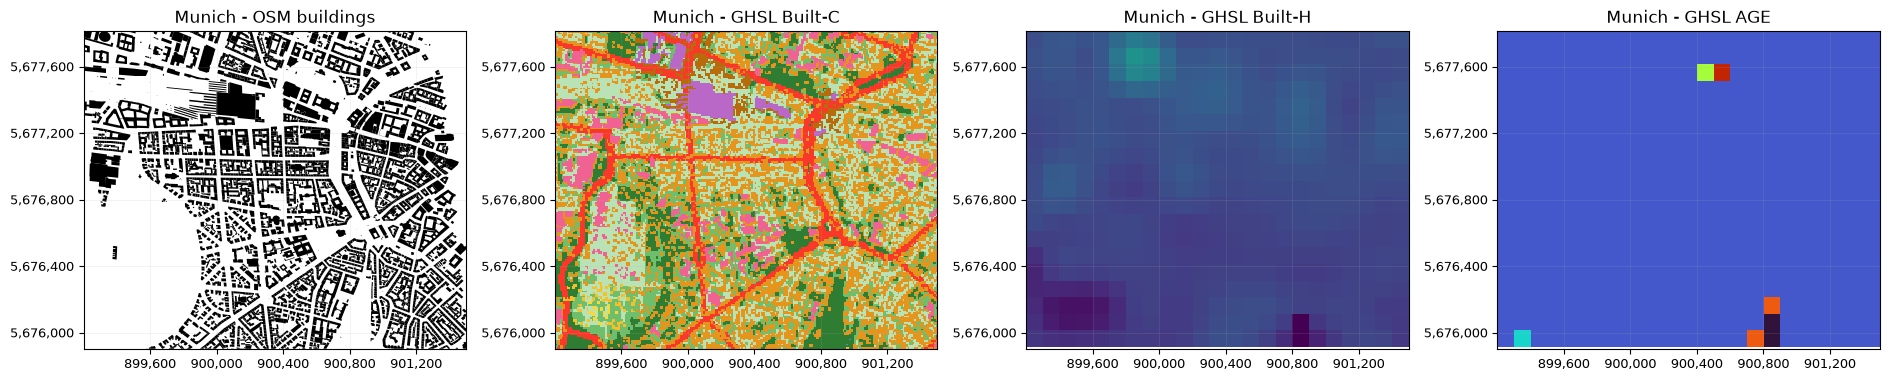

Munich: 3161 OSM footprints drawn (capped at 5000), Built-C 230x191 px at 10 m, Built-H and AGE resampled onto that grid from 100 m. CRS ESRI:54009.


In [13]:
CITY = "Munich"   # any value of city_assets_df["city_ghsl"]

row = city_assets_df.loc[city_assets_df["city_key"] == clean_city_name(CITY)]
if row.empty:
    raise ValueError(f"{CITY} is not in city_assets_df")
row = row.iloc[0]

buildings = load_city_buildings(row["osm_pbf"], MAX_FEATS_PER_CITY)

# Built-C has the finest resolution (10 m), so it defines the shared grid.
with rasterio.open(BUILTC_DIR / row["builtc_tif"]) as ds:
    builtc = np.ma.masked_equal(ds.read(1), ds.nodata)
    grid_crs, grid_transform, grid_shape = ds.crs, ds.transform, ds.shape
    grid_res = ds.res[0]
    left, bottom, right, top = ds.bounds


def on_builtc_grid(path):
    """Resample a 100 m chip onto the Built-C grid, padding the edges with NaN."""
    target = np.full(grid_shape, np.nan, dtype="float32")
    with rasterio.open(path) as ds:
        reproject(
            source=ds.read(1).astype("float32"), destination=target,
            src_transform=ds.transform, src_crs=ds.crs, src_nodata=ds.nodata,
            dst_transform=grid_transform, dst_crs=grid_crs, dst_nodata=np.nan,
            resampling=Resampling.nearest,
        )
    return np.ma.masked_invalid(target)


builth = on_builtc_grid(BUILTH_DIR / row["builth_tif"])
age = on_builtc_grid(AGE_DIR / row["builtage_tif"])

extent = (left, right, bottom, top)
fig, axes = plt.subplots(1, 4, figsize=(19, 5))

gpd.clip(buildings.to_crs(grid_crs), box(left, bottom, right, top)).plot(
    ax=axes[0], linewidth=0.0, facecolor="black")
axes[0].set_title(f"{CITY} - OSM buildings", fontsize=12)

for ax, (array, title, style) in zip(axes[1:], [
    (builtc, "GHSL Built-C", dict(cmap=BUILTC_CMAP, norm=BUILTC_NORM)),
    (builth, "GHSL Built-H", dict(cmap="viridis", vmin=0, vmax=50)),
    (age, "GHSL AGE", dict(cmap=AGE_CMAP, norm=AGE_NORM)),
]):
    ax.imshow(array, extent=extent, origin="upper", interpolation="nearest", **style)
    ax.set_title(f"{CITY} - {title}", fontsize=12)

for ax in axes:
    ax.set_xlim(left, right)
    ax.set_ylim(bottom, top)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.tick_params(labelsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.tight_layout()
plt.show()

print(f"{CITY}: {len(buildings)} OSM footprints drawn (capped at {MAX_FEATS_PER_CITY}), "
      f"Built-C {grid_shape[1]}x{grid_shape[0]} px at {grid_res:.0f} m, "
      f"Built-H and AGE resampled onto that grid from 100 m. CRS {grid_crs}.")

## Save the city indicators and the source-asset registry

The two tables are saved separately so their schemas and their roles stay explicit to the later
stages. `extracted_attributes.csv` is the same table as `cities_df.pkl`, written here as well so
the city list can be read without Python.

**Outputs**

- `data/interim/cities_df.pkl`: the GHSL indicators, keyed by `city_key`
- `data/interim/city_assets_df.pkl`: coordinates and the OSM and GHSL source filenames, keyed by `city_key`
- `data/interim/extracted_attributes.csv`: `cities_df.pkl` as CSV


In [14]:
cities_path = INTERIM_DIR / "cities_df.pkl"
assets_path = INTERIM_DIR / "city_assets_df.pkl"
attributes_csv = INTERIM_DIR / "extracted_attributes.csv"

cities_df.to_pickle(cities_path)
city_assets_df.to_pickle(assets_path)
cities_df.to_csv(attributes_csv, index=False)   # the same table, for reading outside Python

for name, path in [("cities_df", cities_path), ("city_assets_df", assets_path),
                   ("extracted_attributes", attributes_csv)]:
    print(f"{name:20s} -> {display_path(path)} ({path.stat().st_size / 1e6:.2f} MB)")

cities_df            -> data/interim/cities_df.pkl (0.18 MB)
city_assets_df       -> data/interim/city_assets_df.pkl (0.14 MB)
extracted_attributes -> data/interim/extracted_attributes.csv (0.24 MB)


# Optional: remove the large source files to free disk space

Run the cell below only after checking that every per-city output is present and correct. It deletes the large downloads that the later stages no longer need.

| File or directory | Size, extracted | Safe to delete once |
|---|---|---|
| `data/GHSL/GHS_BUILT_C_MSZ_.../*.tif` | ~69 GB (global 10 m tile set) | every Built-C chip in `GHS_BuiltC_cities/` is verified |
| `data/OSM PBF/country_pbf/` | ~27 GB for the 27 countries | every per-city PBF in `cities_osm_pbf/` is verified |
| `data/GHSL/GHS_BUILT_H_ANBH_...tif` | ~3.6 GB | every Built-H chip in `GHS_BuiltH_cities/` is verified |
| `data/GHSL/GHS_AGE_...tif` | ~1.1 GB | every AGE chip in `GHS_BuiltAge_cities/` is verified |

The downloaded `.zip` archives can go too, once their contents are extracted: another ~16 GB.

Keep the per-city outputs - the chips, the extracts, `cities_df.pkl` and `city_assets_df.pkl`: they are the inputs of the later notebooks.


In [15]:
# Optional cleanup. Deletions are permanent, so confirm the interim tables and chip directories first.

# Per-country OSM PBFs (100 MB to 6 GB each)
# for pbf in sorted(COUNTRY_PBF_DIR.glob("*.osm.pbf")):
#     pbf.unlink()

# GHSL global rasters
# BUILTH_RASTER.unlink()
# AGE_RASTER.unlink()
# for tile in BUILTC_TILES.glob("**/*.tif"):
#     tile.unlink()